In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
df = pd.read_csv("../data/telco-customer-churn.csv")

In [46]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df.dropna(inplace=True)

df.drop("customerID", axis=1, inplace=True)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [47]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
model_rfc = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model_rfc.fit(X_train, y_train)

y_pred_rfc = model_rfc.predict(X_test)

In [51]:
accuracy = accuracy_score(y_test, y_pred_rfc)
print("Random Forest Classifier\n")
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred_rfc))

Random Forest Classifier

Accuracy: 0.8009950248756219
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.67      0.49      0.57       374

    accuracy                           0.80      1407
   macro avg       0.75      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



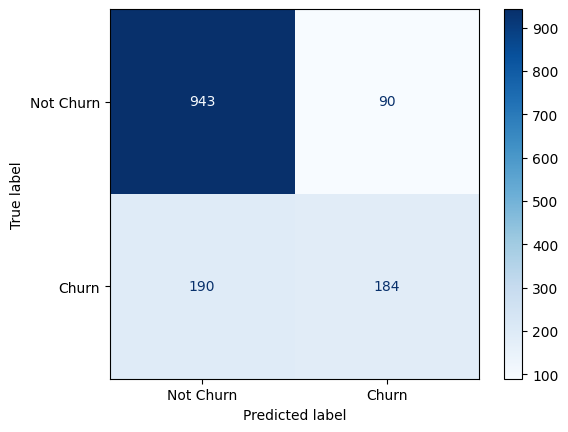

In [50]:
cm = confusion_matrix(y_test, y_pred_rfc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churn","Churn"]
)

disp.plot(cmap="Blues")
plt.show()